# PyTorch Custom Dataset Pipeline


In [1]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image

import time
import shutil
import random
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

- Load binary image data (Agri vs Non-Agri)
- Custom Dataset: paths + labels, shuffle, (img, label)
- Transforms: resize + augment + normalize
- ImageFolder: auto-label from folders
- DataLoader: batching (8), shuffle
- Output: images [B,3,H,W], labels [B]
- Visualize: denormalize + plot grid

In [3]:
class CustomeBinaryClassification(Dataset):
    def __init__(self, non_agri_dir, agri_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for fname in os.listdir(non_agri_dir):
            self.image_paths.append(os.path.join(non_agri_dir, fname))
            self.labels.append(0)
            
        for fname in os.listdir(agri_dir):
            self.image_paths.append(os.path.join(agri_dir, fname))
            self.labels.append(1)

        temp = list(zip(self.image_paths, self.labels))
        np.random.shuffle(temp)
        self.image_paths, self.labels = zip(*temp)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB") 
        
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [4]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [6]:
BATCH_SIZE = 8 

custom_dataset = CustomeBinaryClassification(
    dir_non_agri, 
    dir_agri, 
    transform=custom_transform
)
custom_loader = DataLoader(
    custom_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


On Windows, Jupyter can't spawn background worker processes, so num_workers=2 causes everything to freeze indefinitely.

In [7]:
images_custom, labels_custom = next(iter(custom_loader))

print(f"Images batch shape (Custom loader): {images_custom.shape}") 
print(f"Labels batch shape (Custom loader): {labels_custom.shape}")

Images batch shape (Custom loader): torch.Size([8, 3, 64, 64])
Labels batch shape (Custom loader): torch.Size([8])


In [8]:
def imshow(img):
    img = img.detach().cpu()
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Convert from C,H,W to H,W,C

The .detach().cpu() is still a good practice to keep — it explicitly tells PyTorch "don't track gradients, make sure this is on CPU" before converting to numpy. Safer to have it.

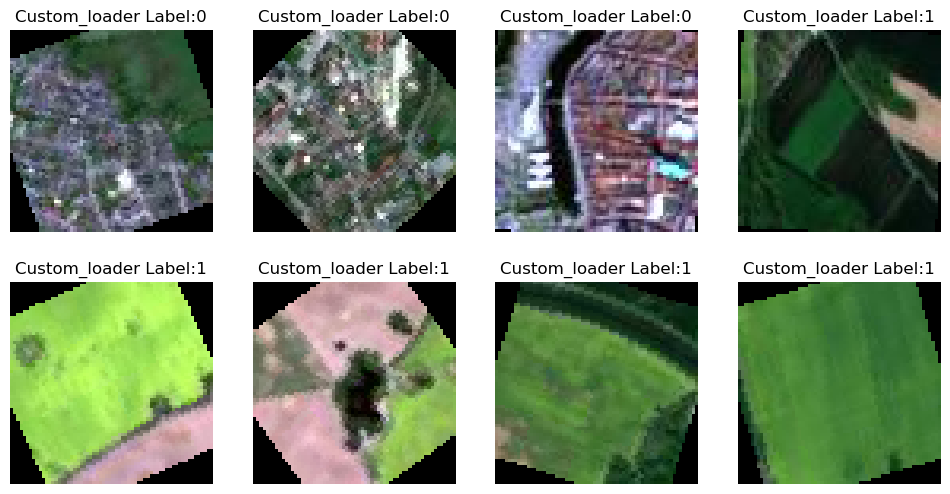

In [9]:
plt.figure(figsize=(12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_custom[i])
    plt.title(f"Custom_loader Label:{labels_custom[i].item()}")
    plt.axis("off")

In [10]:
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)   

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark     = False 

In [11]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} — main process is now deterministic.")

Global seed set to 42 — main process is now deterministic.


In [12]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed) 
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)